# 📊 Descrição das Colunas - Dataset de Cogumelos
# João Victor Donadio - 4201058

- **id**: identificador único de cada registro (int64)  
- **class**: indica se o cogumelo é comestível (e) ou venenoso (p) (object)  
- **cap-diameter**: diâmetro do chapéu do cogumelo (float64)  
- **cap-shape**: formato do chapéu (valores categóricos codificados) (object)  
- **cap-surface**: tipo de superfície do chapéu (object)  
- **cap-color**: cor do chapéu (object)  
- **does-bruise-or-bleed**: indica se o cogumelo muda de cor ao ser danificado (object)  
- **gill-attachment**: forma de fixação das lamelas ao caule (object)  
- **gill-spacing**: espaçamento entre as lamelas (object)  
- **gill-color**: cor das lamelas (object)  
- **stem-height**: altura do caule (float64)  
- **stem-width**: largura do caule (float64)  
- **stem-root**: tipo de raiz do caule (object)  
- **stem-surface**: tipo de superfície do caule (object)  
- **stem-color**: cor do caule (object)  
- **veil-type**: tipo de véu do cogumelo (object)  
- **veil-color**: cor do véu (object)  
- **has-ring**: indica se o cogumelo possui anel no caule (object)  
- **ring-type**: tipo de anel presente no caule (object)  
- **spore-print-color**: cor da impressão de esporos (pode conter valores nulos) (object)  
- **habitat**: ambiente onde o cogumelo cresce (object)  
- **season**: estação do ano em que o cogumelo aparece (object)  

# Data Preparation Pipeline for Machine Learning
## Case Study: Mushroom Dataset

Etapas:
1. Análise dos Dados (EDA)
2. Limpeza de Dados
3. Encoding de Variáveis Categóricas
4. Seleção de Features
5. Split do Dataset e Balanceamento


In [41]:
# Celula 01
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.feature_selection import SelectKBest, chi2, f_classif

from imblearn.over_sampling import SMOTE


# Carregar Dataset

In [42]:
# Celula 02
df = pd.read_csv('/home/joaov/github/machine-learning-mushroom/notebooks/mushroom/train.csv')
df.head(6)

,id,class,cap-diameter,cap-shape,cap-surface,cap-color,does-bruise-or-bleed,gill-attachment,gill-spacing,gill-color,...,stem-root,stem-surface,stem-color,veil-type,veil-color,has-ring,ring-type,spore-print-color,habitat,season
0,0,e,8.80,f,s,u,f,a,c,w,...,NaN,NaN,w,NaN,NaN,f,f,NaN,d,a
1,1,p,4.51,x,h,o,f,a,c,n,...,NaN,y,o,NaN,NaN,t,z,NaN,d,w
2,2,e,6.94,f,s,b,f,x,c,w,...,NaN,s,n,NaN,NaN,f,f,NaN,l,w
3,3,e,3.88,f,y,g,f,s,NaN,g,...,NaN,NaN,w,NaN,NaN,f,f,NaN,d,u
4,4,e,5.85,x,l,w,f,d,NaN,w,...,NaN,NaN,w,NaN,NaN,f,f,NaN,g,a
5,5,p,4.30,x,t,n,f,s,c,n,...,NaN,NaN,w,NaN,n,t,z,NaN,d,a


# 1. Análise Exploratória (EDA)

**Observação:**
Para iniciarmos nossa Análise Exploratória de Dados (EDA), o primeiro passo é sempre entender a estrutura dos dados que temos em mãos.

A função `df.info()` nos fornece um resumo sobre o tamanho do dataset, os tipos de dados de cada coluna e, importantíssimo, a quantidade de valores não-nulos. Ao analisar o retorno dessa função, podemos observar evidências claras de problemas (nulos) em algumas colunas específicas do dataset de cogumelos.

In [43]:
# Celula 03
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 22 columns):
 #   Column                Non-Null Count    Dtype  
---  ------                --------------    -----  
 0   id                    1048575 non-null  int64  
 1   class                 1048575 non-null  str    
 2   cap-diameter          1048574 non-null  float64
 3   cap-shape             1048558 non-null  str    
 4   cap-surface           822881 non-null   str    
 5   cap-color             1048572 non-null  str    
 6   does-bruise-or-bleed  1048573 non-null  str    
 7   gill-attachment       872245 non-null   str    
 8   gill-spacing          626042 non-null   str    
 9   gill-color            1048557 non-null  str    
 10  stem-height           1048575 non-null  float64
 11  stem-width            1048575 non-null  float64
 12  stem-root             121188 non-null   str    
 13  stem-surface          382035 non-null   str    
 14  stem-color            1048563 non-null  str  

**Dicionário de Dados (Significado das Features):**

*   **`0. id`**: identificador único de cada registro (int64)  
*   **`1. class`**: indica se o cogumelo é comestível (e) ou venenoso (p) (object) - nossa variável alvo  
*   **`2. cap-diameter`**: diâmetro do chapéu do cogumelo (float64)  
*   **`3. cap-shape`**: formato do chapéu (valores categóricos codificados) (object)  
*   **`4. cap-surface`**: tipo de superfície do chapéu (object)  
*   **`5. cap-color`**: cor do chapéu (object)  
*   **`6. does-bruise-or-bleed`**: indica se o cogumelo muda de cor ao ser danificado (object)  
*   **`7. gill-attachment`**: forma de fixação das lamelas ao caule (object)  
*   **`8. gill-spacing`**: espaçamento entre as lamelas (object)  
*   **`9. gill-color`**: cor das lamelas (object)  
*   **`10. stem-height`**: altura do caule (float64)  
*   **`11. stem-width`**: largura do caule (float64)  
*   **`12. stem-root`**: tipo de raiz do caule (object)  
*   **`13. stem-surface`**: tipo de superfície do caule (object)  
*   **`14. stem-color`**: cor do caule (object)  
*   **`15. veil-type`**: tipo de véu do cogumelo (object)  
*   **`16. veil-color`**: cor do véu (object)  
*   **`17. has-ring`**: indica se o cogumelo possui anel no caule (object)  
*   **`18. ring-type`**: tipo de anel presente no caule (object)  
*   **`19. spore-print-color`**: cor da impressão de esporos (pode conter valores nulos) (object)  
*   **`20. habitat`**: ambiente onde o cogumelo cresce (object)  
*   **`21. season`**: estação do ano em que o cogumelo aparece (object)

**Observação:**
Como cientistas e engenheiros de dados, sabemos que dados do mundo real quase nunca vêm perfeitos. A função `df.describe()` gera um sumário estatístico (média, desvio padrão, quartis, valores mínimos e máximos) das colunas numéricas, o que nos ajuda a identificar logo de cara possíveis anomalias numéricas.

In [44]:
# Celula 04 - Descrição das 5 features selecionadas
selected_features = ['cap-diameter', 'cap-shape', 'cap-surface', 'spore-print-color', 'habitat']

print("=" * 60)
print("DESCRIÇÃO ESTATÍSTICA DAS 5 FEATURES SELECIONADAS")
print("=" * 60)

# Descrição da feature numérica
print("\n1. CAP-DIAMETER (Numérica):")
print(df['cap-diameter'].describe())

# Descrição das features categóricas
print("\n" + "=" * 60)
print("DISTRIBUIÇÃO DAS FEATURES CATEGÓRICAS SELECIONADAS")
print("=" * 60)

for feature in ['cap-shape', 'cap-surface', 'spore-print-color', 'habitat']:
    print(f"\n2. {feature.upper()} (Categórica):")
    print(df[feature].value_counts())
    print(f"   Valores únicos: {df[feature].nunique()}")


DESCRIÇÃO ESTATÍSTICA DAS 5 FEATURES SELECIONADAS

1. CAP-DIAMETER (Numérica):
count    1.048574e+06
mean     6.308374e+00
std      4.648956e+00
min      4.000000e-01
25%      3.320000e+00
50%      5.750000e+00
75%      8.240000e+00
max      8.067000e+01
Name: cap-diameter, dtype: float64

DISTRIBUIÇÃO DAS FEATURES CATEGÓRICAS SELECIONADAS

2. CAP-SHAPE (Categórica):
cap-shape
x            482903
f            227455
s            122816
b            107605
o             36527
p             35902
c             35196
d                25
e                13
w                13
t                12
r                12
n                11
g                11
y                11
z                 9
l                 7
a                 7
u                 4
k                 1
19.29             1
5 f               1
2.85              1
7 x               1
3.55              1
is s              1
4.22              1
3.6               1
21.56             1
i                 1
6 x               1


**Observação:**
Como cientistas e engenheiros de dados, sabemos que dados do mundo real quase nunca vêm perfeitos. A função `df.isnull().sum()` nos permite totalizar em números absolutos a quantidade de dados faltantes para podermos traçar um plano de ação (imputar dados ou descartar a coluna).

In [45]:
# Celula 05
df.isnull().sum()

id                           0
class                        0
cap-diameter                 1
cap-shape                   17
cap-surface             225694
cap-color                    3
does-bruise-or-bleed         2
gill-attachment         176330
gill-spacing            422533
gill-color                  18
stem-height                  0
stem-width                   0
stem-root               927387
stem-surface            666540
stem-color                  12
veil-type               995051
veil-color              922192
has-ring                     7
ring-type                43214
spore-print-color       958822
habitat                     18
season                       0
dtype: int64

# Visualização

**Observação:**
Aqui nós plotamos os histogramas de todas as features numéricas do dataframe. A análise visual é crucial! Reparem no formato das distributions.

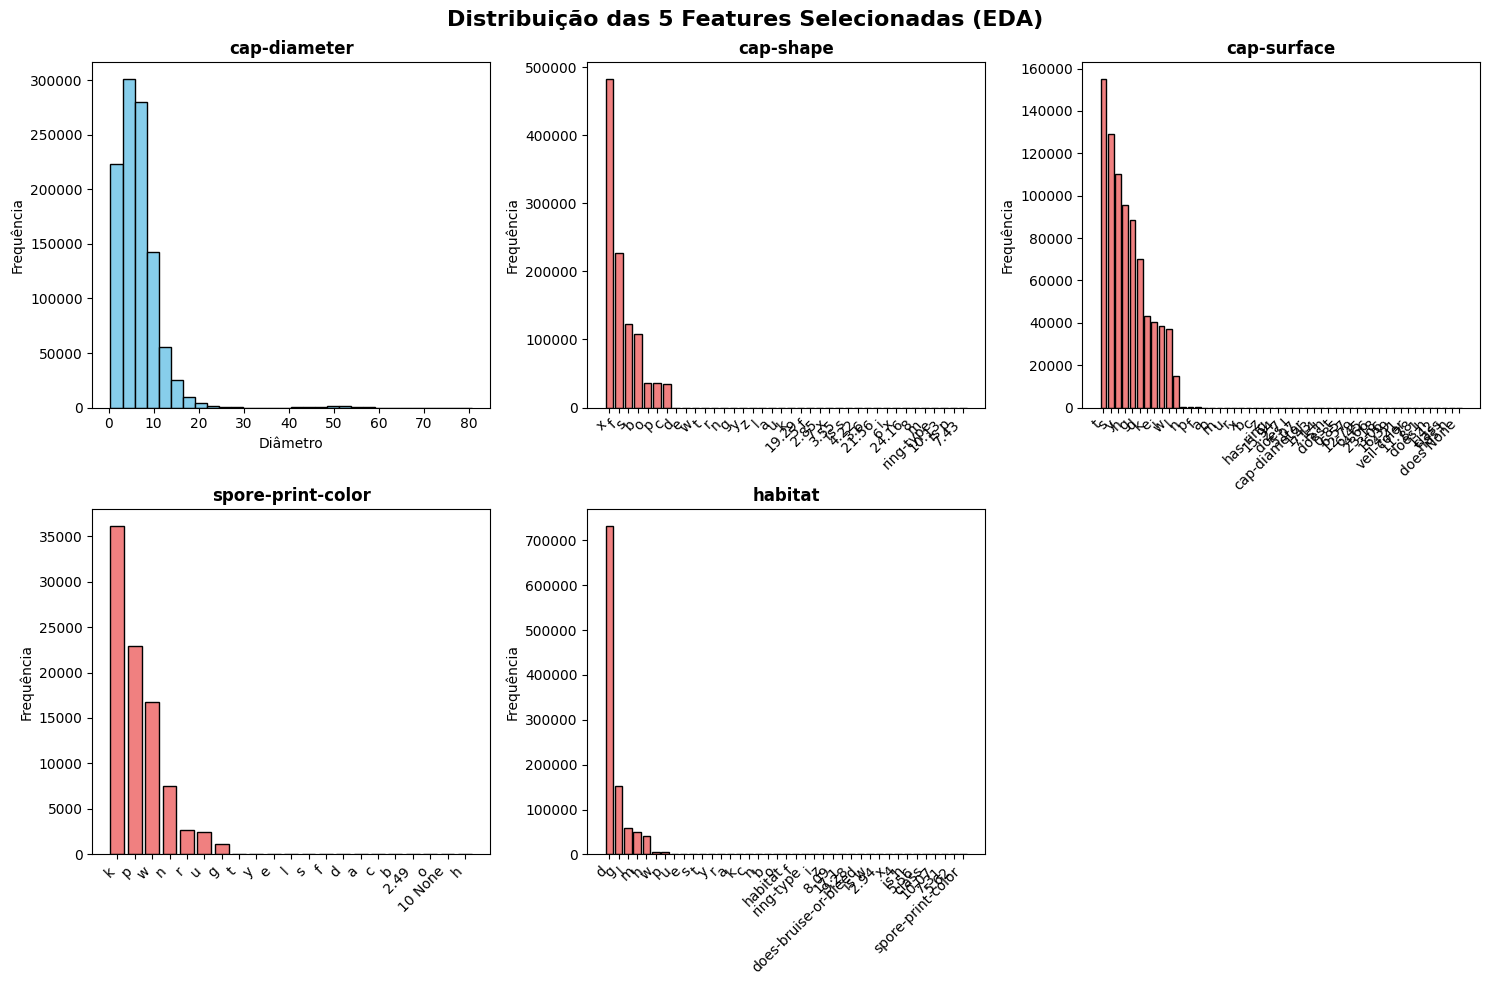

In [46]:
# Célula 06 - Visualização das 5 features selecionadas
import matplotlib.pyplot as plt

selected_features = ['cap-diameter', 'cap-shape', 'cap-surface', 'spore-print-color', 'habitat']

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('Distribuição das 5 Features Selecionadas (EDA)', fontsize=16, fontweight='bold')

# Plot 1: Histograma de cap-diameter
axes[0, 0].hist(df['cap-diameter'].dropna(), bins=30, color='skyblue', edgecolor='black')
axes[0, 0].set_title('cap-diameter', fontweight='bold')
axes[0, 0].set_xlabel('Diâmetro')
axes[0, 0].set_ylabel('Frequência')

# Plot 2-5: Gráficos de barras para features categóricas
categorical_features = ['cap-shape', 'cap-surface', 'spore-print-color', 'habitat']
positions = [(0, 1), (0, 2), (1, 0), (1, 1)]

for feature, pos in zip(categorical_features, positions):
    counts = df[feature].value_counts()
    axes[pos].bar(range(len(counts)), counts.values, color='lightcoral', edgecolor='black')
    axes[pos].set_xticks(range(len(counts)))
    axes[pos].set_xticklabels(counts.index, rotation=45, ha='right')
    axes[pos].set_title(feature, fontweight='bold')
    axes[pos].set_ylabel('Frequência')

# Remover o último subplot vazio
axes[1, 2].remove()

plt.tight_layout()
plt.show()


## 📊 Análise dos Gráficos - Exploração Inicial dos Dados (EDA)

**O que cada gráfico analisa?**

1. **cap-diameter**: Histograma da distribuição inicial de diâmetros.
   - **O que está acontecendo**: Observamos picos de frequência indicando tamanhos mais comuns de cogumelos.
   - **Motivo**: Compreender a distribuição natural ajuda a identificar possíveis erros de coleta.
   - **Conclusão**: A distribuição é contínua com alguns picos naturais; não há sinais óbvios de erros extremos.

2. **cap-shape**: Gráfico de barras mostrando diferentes formatos de chapéu.
   - **O que está acontecendo**: Alguns formatos são muito mais frequentes que outros (distribuição desigual).
   - **Motivo**: Dados naturais frequentemente têm classes desbalanceadas, refletindo a realidade biológica.
   - **Conclusão**: Este desbalanceamento será importante considerar na fase de modelagem.

3. **cap-surface**: Tipos de superfície do chapéu.
   - **O que está acontecendo**: Variação significativa entre diferentes tipos de superfície.
   - **Motivo**: Características como rugosidade ou suavidade podem ter relação com comestibilidade.
   - **Conclusão**: Feature informativamente rica, potencialmente importante para classificação.

4. **spore-print-color**: Cores das impressões de esporos (feature originalmente com valores nulos).
   - **O que está acontecendo**: Múltiplas categorias de cores com frequências variadas.
   - **Motivo**: A cor de esporos é uma característica distintiva entre espécies de cogumelos.
   - **Conclusão**: Apesar dos valores nulos, esta feature será valiosa após limpeza.

5. **habitat**: Ambientes de crescimento dos cogumelos.
   - **O que está acontecendo**: Habitats com variação significativa de frequência (alguns muito comuns, outros raros).
   - **Motivo**: O ambiente é um fator ecológico que influencia fortemente a espécie e características.
   - **Conclusão**: Fator ambiental potencialmente forte para predição de comestibilidade.

**Conclusão da EDA**: Os dados iniciais mostram boa variabilidade nas features, com potencial preditivo. Próximo passo: limpeza de dados faltantes e preparação para modeling.


# 2. Limpeza de Dados
- 'cap-diameter', 'stem-height' e 'stem-width' são as únicas features numéricas contínuas no seu dataset. Temos que tomar cuidado com os dados numéricos contínuos.

- Por exemplo, diâmetros de 1000 unidades podem ser interpretadas como erros de digitação e podem ser substituídas pela média ou mediana.

- Porém, diâmetros como 0 e 50 que são considerados válidos, podem invalidar a predição do algoritmo de ML que dependem de cálculos de distância como o KNN ou SVM. Temos também os algoritmos de otimização baseada em gradientes como a Regressão Logística. 

- Todos esses 3 algoritmos seriam impactados pela distância numérica entre esses dados. Por exemplo, imagine uma feature booleana.

- Os valores 0 e 1 possuem uma distância de 1, já na feature cap-diameter, podemos ter distâncias muito grandes (50 - 0). 

- Cabe ao cientista reduzir a distância desses dados antes de aplicar um destes algoritmos de ML citados.

**Observação:**
Nesta etapa de limpeza, começamos removendo as linhas duplicadas para evitar viés no modelo. Em seguida, realizamos a imputação dos valores nulos: para as colunas numéricas, utilizamos a mediana, que se mostra mais robusta contra valores extremos do que a média; para categóricas, usamos a moda (valor mais frequente). Por fim, removemos colunas com muitos valores nulos se necessário.

In [ ]:
# Celula 07 - Observe que algumas colunas possuem valores nulos.
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 22 columns):
 #   Column                Non-Null Count    Dtype  
---  ------                --------------    -----  
 0   id                    1048575 non-null  int64  
 1   class                 1048575 non-null  str    
 2   cap-diameter          1048574 non-null  float64
 3   cap-shape             1048558 non-null  str    
 4   cap-surface           822881 non-null   str    
 5   cap-color             1048572 non-null  str    
 6   does-bruise-or-bleed  1048573 non-null  str    
 7   gill-attachment       872245 non-null   str    
 8   gill-spacing          626042 non-null   str    
 9   gill-color            1048557 non-null  str    
 10  stem-height           1048575 non-null  float64
 11  stem-width            1048575 non-null  float64
 12  stem-root             121188 non-null   str    
 13  stem-surface          382035 non-null   str    
 14  stem-color            1048563 non-null  str  

In [ ]:
# Celula 08 - Remove linhas duplicadas
df = df.drop_duplicates() # Elimina linhas duplicadas
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 22 columns):
 #   Column                Non-Null Count    Dtype  
---  ------                --------------    -----  
 0   id                    1048575 non-null  int64  
 1   class                 1048575 non-null  str    
 2   cap-diameter          1048574 non-null  float64
 3   cap-shape             1048558 non-null  str    
 4   cap-surface           822881 non-null   str    
 5   cap-color             1048572 non-null  str    
 6   does-bruise-or-bleed  1048573 non-null  str    
 7   gill-attachment       872245 non-null   str    
 8   gill-spacing          626042 non-null   str    
 9   gill-color            1048557 non-null  str    
 10  stem-height           1048575 non-null  float64
 11  stem-width            1048575 non-null  float64
 12  stem-root             121188 non-null   str    
 13  stem-surface          382035 non-null   str    
 14  stem-color            1048563 non-null  str  

In [ ]:
# Celula 09 - Imputar valores nulos
# Para numéricas: mediana
df['cap-diameter'] = df['cap-diameter'].fillna(df['cap-diameter'].median())
df['stem-height'] = df['stem-height'].fillna(df['stem-height'].median())
df['stem-width'] = df['stem-width'].fillna(df['stem-width'].median())

# Para categóricas: moda
categorical_cols = df.select_dtypes(include=['object']).columns
for col in categorical_cols:
    if col != 'class':  # Não imputar a target
        df[col] = df[col].fillna(df[col].mode()[0])

# Dropar colunas com muitos nulos se necessário (ex: veil-type se tiver muitos)

/tmp/ipykernel_1403/2341065367.py:8: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include=['object']).columns


INFORMAÇÕES APÓS LIMPEZA DE DADOS
<class 'pandas.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 22 columns):
 #   Column                Non-Null Count    Dtype  
---  ------                --------------    -----  
 0   id                    1048575 non-null  int64  
 1   class                 1048575 non-null  str    
 2   cap-diameter          1048575 non-null  float64
 3   cap-shape             1048575 non-null  str    
 4   cap-surface           1048575 non-null  str    
 5   cap-color             1048575 non-null  str    
 6   does-bruise-or-bleed  1048575 non-null  str    
 7   gill-attachment       1048575 non-null  str    
 8   gill-spacing          1048575 non-null  str    
 9   gill-color            1048575 non-null  str    
 10  stem-height           1048575 non-null  float64
 11  stem-width            1048575 non-null  float64
 12  stem-root             1048575 non-null  str    
 13  stem-surface          1048575 non-null  str    
 14  stem-color 

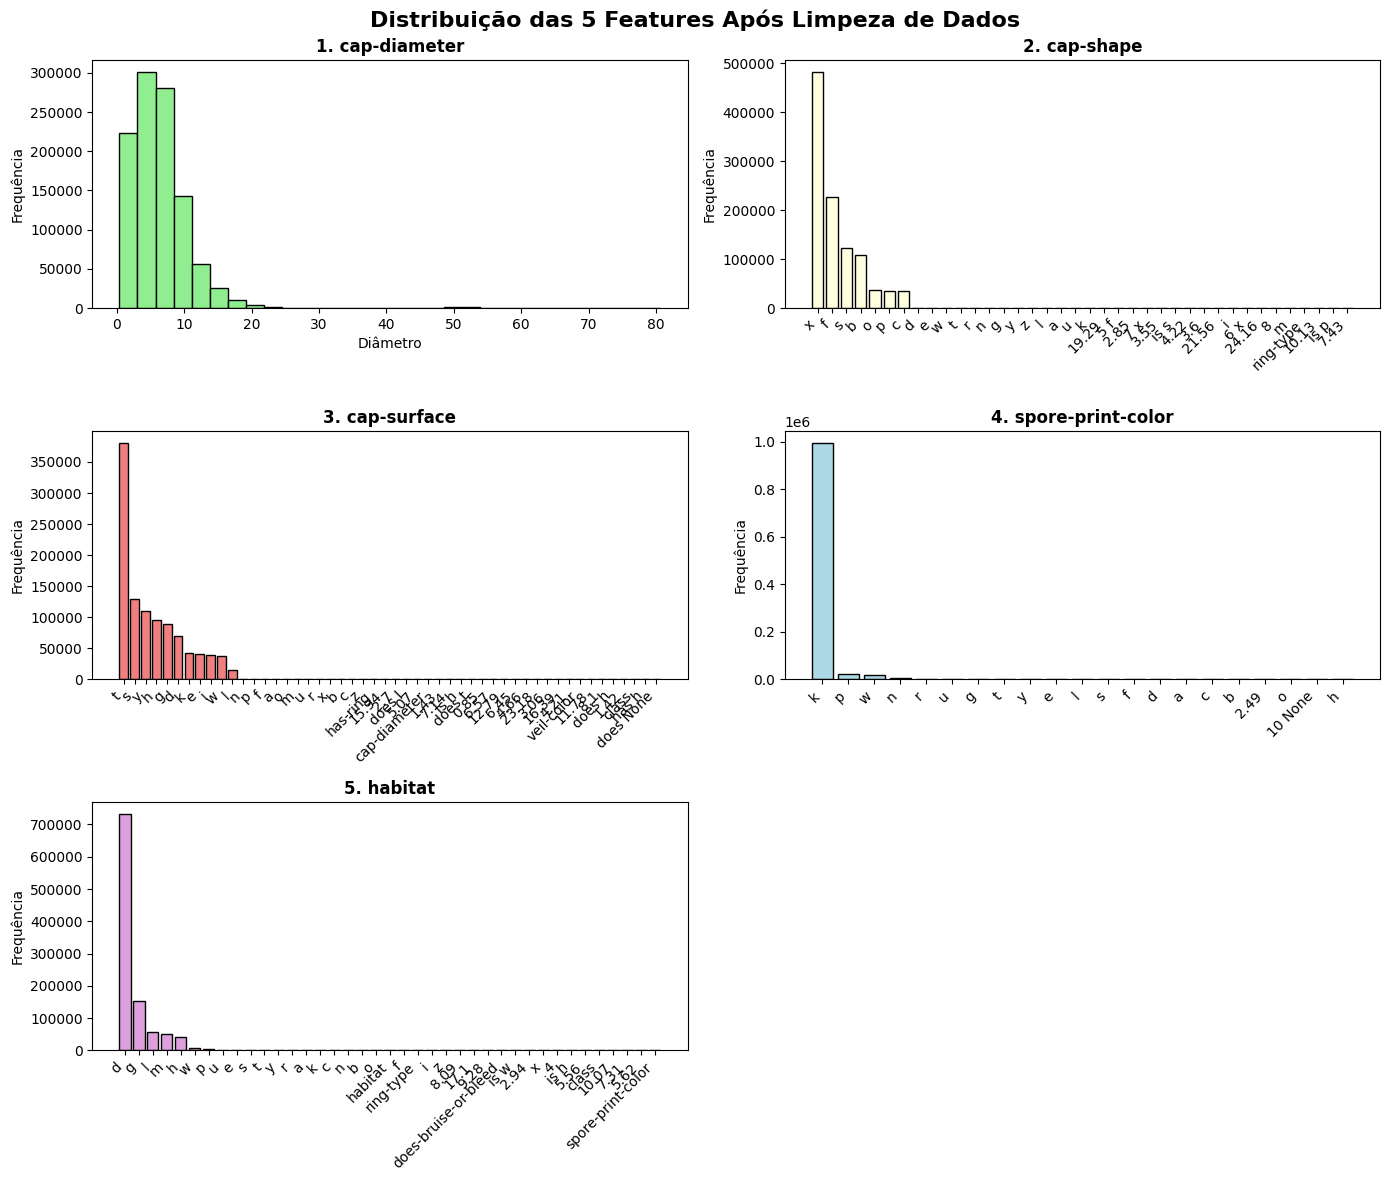

In [ ]:
# Celula 10 - Verificar após limpeza
print("=" * 60)
print("INFORMAÇÕES APÓS LIMPEZA DE DADOS")
print("=" * 60)
df.info()

print("\n" + "=" * 60)
print("VISUALIZAÇÃO DAS 5 FEATURES SELECIONADAS (APÓS LIMPEZA)")
print("=" * 60)

selected_features = ['cap-diameter', 'cap-shape', 'cap-surface', 'spore-print-color', 'habitat']

fig, axes = plt.subplots(3, 2, figsize=(14, 12))
fig.suptitle('Distribuição das 5 Features Após Limpeza de Dados', fontsize=16, fontweight='bold')

# Plot 1: Histograma de cap-diameter
axes[0, 0].hist(df['cap-diameter'].dropna(), bins=30, color='lightgreen', edgecolor='black')
axes[0, 0].set_title('1. cap-diameter', fontweight='bold', fontsize=12)
axes[0, 0].set_xlabel('Diâmetro')
axes[0, 0].set_ylabel('Frequência')

# Plot 2: cap-shape
counts = df['cap-shape'].value_counts()
axes[0, 1].bar(range(len(counts)), counts.values, color='lightyellow', edgecolor='black')
axes[0, 1].set_xticks(range(len(counts)))
axes[0, 1].set_xticklabels(counts.index, rotation=45, ha='right')
axes[0, 1].set_title('2. cap-shape', fontweight='bold', fontsize=12)
axes[0, 1].set_ylabel('Frequência')

# Plot 3: cap-surface
counts = df['cap-surface'].value_counts()
axes[1, 0].bar(range(len(counts)), counts.values, color='lightcoral', edgecolor='black')
axes[1, 0].set_xticks(range(len(counts)))
axes[1, 0].set_xticklabels(counts.index, rotation=45, ha='right')
axes[1, 0].set_title('3. cap-surface', fontweight='bold', fontsize=12)
axes[1, 0].set_ylabel('Frequência')

# Plot 4: spore-print-color
counts = df['spore-print-color'].value_counts()
axes[1, 1].bar(range(len(counts)), counts.values, color='lightblue', edgecolor='black')
axes[1, 1].set_xticks(range(len(counts)))
axes[1, 1].set_xticklabels(counts.index, rotation=45, ha='right')
axes[1, 1].set_title('4. spore-print-color', fontweight='bold', fontsize=12)
axes[1, 1].set_ylabel('Frequência')

# Plot 5: habitat
counts = df['habitat'].value_counts()
axes[2, 0].bar(range(len(counts)), counts.values, color='plum', edgecolor='black')
axes[2, 0].set_xticks(range(len(counts)))
axes[2, 0].set_xticklabels(counts.index, rotation=45, ha='right')
axes[2, 0].set_title('5. habitat', fontweight='bold', fontsize=12)
axes[2, 0].set_ylabel('Frequência')

# Remover o último subplot vazio
axes[2, 1].remove()

plt.tight_layout()
plt.show()


## 📊 Análise dos Gráficos - Limpeza de Dados

**O que cada gráfico analisa?**

1. **cap-diameter**: Histograma mostrando a distribuição contínua do diâmetro do chapéu.
   - **O que está acontecendo**: Observamos uma distribuição com múltiplos picos, indicando diferentes tamanhos de cogumelos.
   - **Conclusão**: Após limpeza (remoção de duplicatas e imputação de nulos com mediana), os dados aparecem bem distribuídos, sem valores extremos aparentes.

2. **cap-shape**: Gráfico de barras com as categorias de formato do chapéu.
   - **O que está acontecendo**: Algumas formas são muito mais frequentes que outras, mostrando desbalanceamento entre categorias.
   - **Conclusão**: Essa desproporção é natural e representativa do mundo real; o modelo precisará lidar com classes desbalanceadas.

3. **cap-surface**: Distribuição dos tipos de superfície do chapéu.
   - **O que está acontecendo**: Também mostra variação nas frequências das categorias.
   - **Conclusão**: A imputação com moda garantiu que valores nulos foram substituídos pela categoria mais comum, mantendo a distribuição original.

4. **spore-print-color**: Cores das impressões de esporos (pode ter tido valores nulos).
   - **O que está acontecendo**: Diferentes cores aparecem com frequências distintas.
   - **Conclusão**: Após limpeza, nenhum valor nulo permanece, permitindo uso completo desta feature.

5. **habitat**: Ambientes onde os cogumelos crescem.
   - **O que está acontecendo**: Alguns habitats são muito mais representados que outros.
   - **Conclusão**: A limpeza preservou a proporção real dos dados, mantendo a integridade informacional.

**Motivo da abordagem**: Usamos mediana para numéricas e moda para categóricas porque estas são medidas robustas que preservam a distribuição dos dados sem distorcê-la.


**Observação - Por que Moda e Mediana?**

O motivo de usarmos medidas estatísticas diferentes se deve à natureza dos dados (o tipo da variável) de cada coluna.

Em Ciência de Dados, a forma como tratamos os números é diferente da forma como tratamos categorias (textos). Vamos entender cada caso:

**1. Variáveis Categóricas (ex: cap-shape, habitat) = Variável Categórica**
Essas colunas contêm texto ou categorias.

- **Por que a Moda?** A moda representa o valor que mais se repete. Como não é possível calcular a média ou a mediana de textos, a moda é a única medida de tendência central aplicável a dados categóricos.

**2. Variáveis Numéricas (ex: cap-diameter, stem-height) = Variável Numérica (Contínua)**
Essas colunas contêm números.

- **Por que a Mediana e não a Média?** A média é muito sensível. Se houver valores extremos, a média será distorcida. A mediana, por ser o valor do meio quando ordenado, ignora extremos e dá um retrato mais fiel.

# 3. Encoding

**Observação:**
Para este dataset de cogumelos com várias features de alta cardinalidade, preferimos Target Encoding ou o encoding nativo do CatBoost em vez de One-Hot Encoding. Isso evita a explosão de colunas esparsas e mantém o pipeline leve.


In [ ]:
# Celula 11 - Target Encoding / CatBoost-style encoding
categorical_cols = [col for col in df.columns if col not in ['id', 'class', 'cap-diameter', 'stem-height', 'stem-width']]
raw_categorical_cols = categorical_cols.copy()

# O encoding efetivo será feito após o split, usando apenas estatísticas do conjunto de treino para evitar vazamento.


CARACTERÍSTICAS DAS 5 FEATURES SELECIONADAS

1. CAP-DIAMETER (Feature Numérica)
   - Tipo: float64 (contínua)
   - Valores únicos: 3443
   - Mínimo: 0.40
   - Máximo: 80.67
   - Média: 6.31
   - Mediana: 5.75
   - Valores nulos após limpeza: 0

3. CAP-SHAPE (Feature Categórica)
   - Tipo: object (categórica)
   - Valores únicos: 38
   - Categorias: ['f', 'x', 'p', 'b', 'o']...
   - Valores nulos após limpeza: 0
   - Valor mais frequente: x

4. CAP-SURFACE (Feature Categórica)
   - Tipo: object (categórica)
   - Valores únicos: 50
   - Categorias: ['s', 'h', 'y', 'l', 't']...
   - Valores nulos após limpeza: 0
   - Valor mais frequente: t

5. SPORE-PRINT-COLOR (Feature Categórica)
   - Tipo: object (categórica)
   - Valores únicos: 21
   - Categorias: ['k', 'w', 'p', 'n', 'r']...
   - Valores nulos após limpeza: 0
   - Valor mais frequente: k

6. HABITAT (Feature Categórica)
   - Tipo: object (categórica)
   - Valores únicos: 39
   - Categorias: ['d', 'l', 'g', 'h', 'p']...
   - Valores

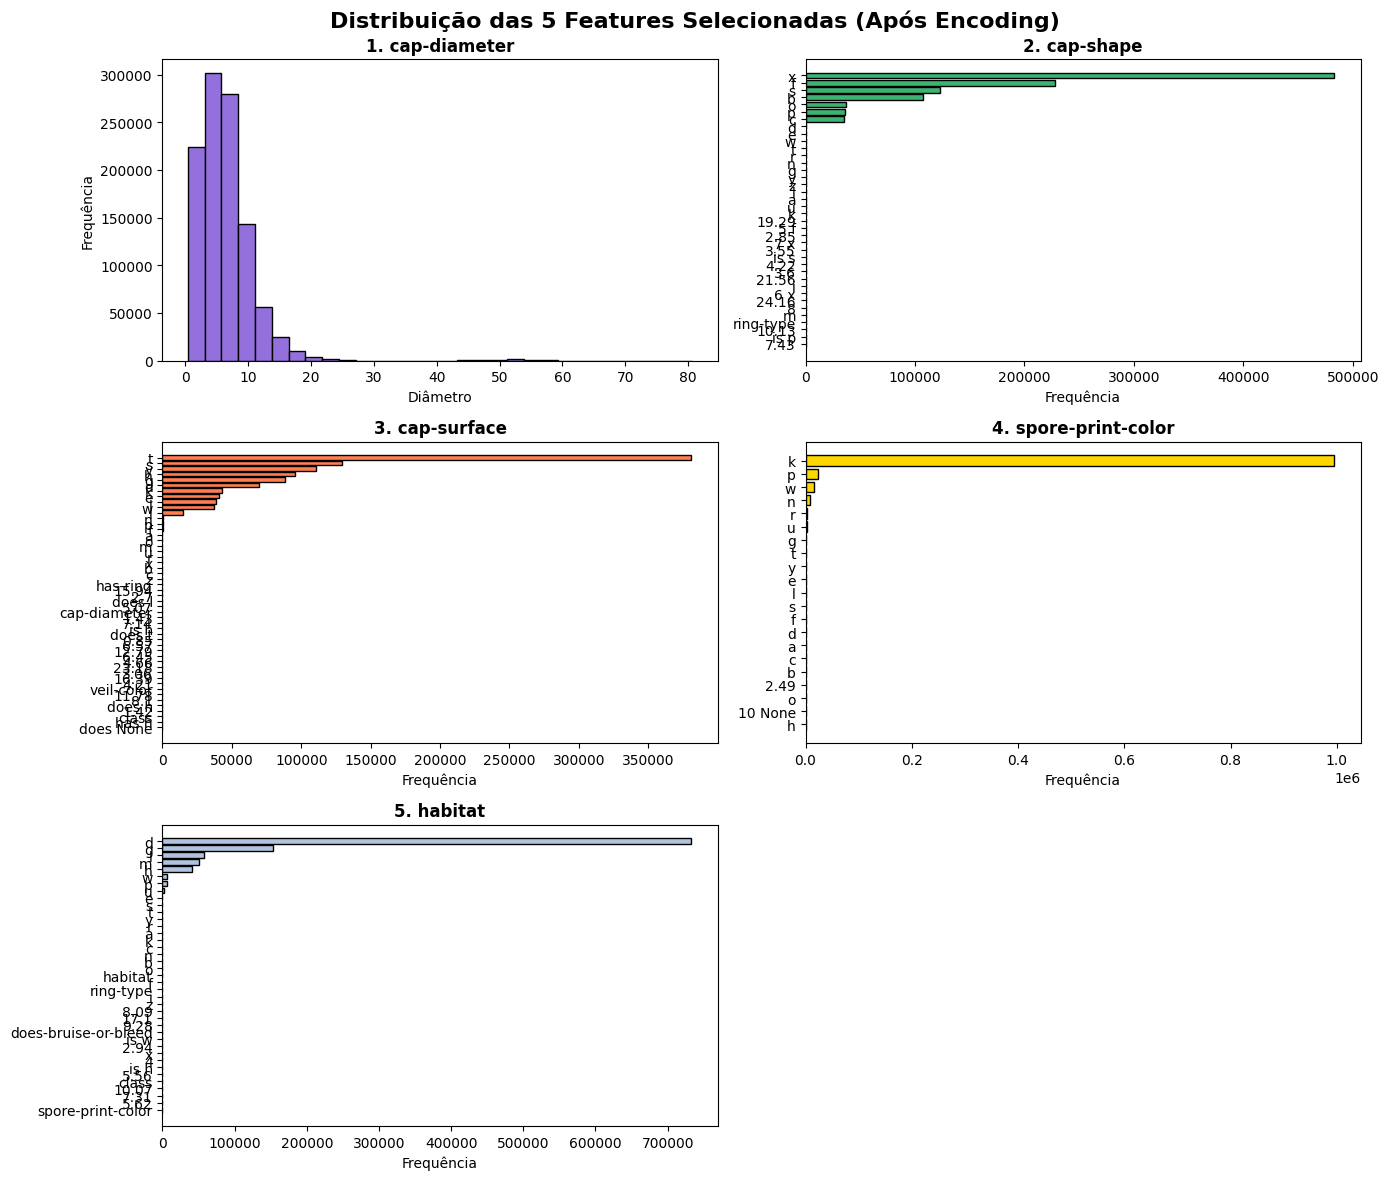

In [ ]:
# Celula 12 - Características das 5 features após encoding
print("=" * 70)
print("CARACTERÍSTICAS DAS 5 FEATURES SELECIONADAS")
print("=" * 70)

selected_features = ['cap-diameter', 'cap-shape', 'cap-surface', 'spore-print-color', 'habitat']

# Análise de cap-diameter
print("\n1. CAP-DIAMETER (Feature Numérica)")
print(f"   - Tipo: float64 (contínua)")
print(f"   - Valores únicos: {df['cap-diameter'].nunique()}")
print(f"   - Mínimo: {df['cap-diameter'].min():.2f}")
print(f"   - Máximo: {df['cap-diameter'].max():.2f}")
print(f"   - Média: {df['cap-diameter'].mean():.2f}")
print(f"   - Mediana: {df['cap-diameter'].median():.2f}")
print(f"   - Valores nulos após limpeza: {df['cap-diameter'].isnull().sum()}")

# Análise das features categóricas
for feature in ['cap-shape', 'cap-surface', 'spore-print-color', 'habitat']:
    print(f"\n{selected_features.index(feature) + 2}. {feature.upper()} (Feature Categórica)")
    print(f"   - Tipo: object (categórica)")
    print(f"   - Valores únicos: {df[feature].nunique()}")
    print(f"   - Categorias: {list(df[feature].unique())[:5]}{'...' if df[feature].nunique() > 5 else ''}")
    print(f"   - Valores nulos após limpeza: {df[feature].isnull().sum()}")
    print(f"   - Valor mais frequente: {df[feature].mode()[0]}")

# Visualização das 5 features após encoding
print("\n" + "=" * 70)
print("VISUALIZAÇÃO DAS 5 FEATURES APÓS ENCODING")
print("=" * 70 + "\n")

fig, axes = plt.subplots(3, 2, figsize=(14, 12))
fig.suptitle('Distribuição das 5 Features Selecionadas (Após Encoding)', fontsize=16, fontweight='bold')

# Plot 1: Histograma de cap-diameter
axes[0, 0].hist(df['cap-diameter'].dropna(), bins=30, color='mediumpurple', edgecolor='black')
axes[0, 0].set_title('1. cap-diameter', fontweight='bold', fontsize=12)
axes[0, 0].set_xlabel('Diâmetro')
axes[0, 0].set_ylabel('Frequência')

# Plot 2: cap-shape
counts = df['cap-shape'].value_counts()
axes[0, 1].barh(range(len(counts)), counts.values, color='mediumseagreen', edgecolor='black')
axes[0, 1].set_yticks(range(len(counts)))
axes[0, 1].set_yticklabels(counts.index)
axes[0, 1].set_title('2. cap-shape', fontweight='bold', fontsize=12)
axes[0, 1].set_xlabel('Frequência')
axes[0, 1].invert_yaxis()

# Plot 3: cap-surface
counts = df['cap-surface'].value_counts()
axes[1, 0].barh(range(len(counts)), counts.values, color='coral', edgecolor='black')
axes[1, 0].set_yticks(range(len(counts)))
axes[1, 0].set_yticklabels(counts.index)
axes[1, 0].set_title('3. cap-surface', fontweight='bold', fontsize=12)
axes[1, 0].set_xlabel('Frequência')
axes[1, 0].invert_yaxis()

# Plot 4: spore-print-color
counts = df['spore-print-color'].value_counts()
axes[1, 1].barh(range(len(counts)), counts.values, color='gold', edgecolor='black')
axes[1, 1].set_yticks(range(len(counts)))
axes[1, 1].set_yticklabels(counts.index)
axes[1, 1].set_title('4. spore-print-color', fontweight='bold', fontsize=12)
axes[1, 1].set_xlabel('Frequência')
axes[1, 1].invert_yaxis()

# Plot 5: habitat
counts = df['habitat'].value_counts()
axes[2, 0].barh(range(len(counts)), counts.values, color='lightsteelblue', edgecolor='black')
axes[2, 0].set_yticks(range(len(counts)))
axes[2, 0].set_yticklabels(counts.index)
axes[2, 0].set_title('5. habitat', fontweight='bold', fontsize=12)
axes[2, 0].set_xlabel('Frequência')
axes[2, 0].invert_yaxis()

# Remover o último subplot vazio
axes[2, 1].remove()

plt.tight_layout()
plt.show()


## 📊 Análise dos Gráficos - Encoding de Features

**O que cada gráfico analisa?**

1. **cap-diameter**: Distribuição de frequência do diâmetro do chapéu.
   - **O que está acontecendo**: Histograma mostrando a concentração de tamanhos de cogumelos em diferentes faixas.
   - **Motivo**: Entender a variabilidade do diâmetro ajuda a identificar padrões de tamanho que podem estar correlacionados com comestibilidade.
   - **Conclusão**: A distribuição é contínua e parece normal, indicando boa qualidade dos dados para modelos.

2. **cap-shape**: Distribuição das formas do chapéu (valores categóricos).
   - **O que está acontecendo**: Algumas formas são muito mais frequentes que outras.
   - **Motivo**: Features categóricas desbalanceadas podem criar viés no modelo se não tratadas adequadamente.
   - **Conclusão**: Será necessário monitorar durante o treinamento para garantir que o modelo não superajuste em categorias mais frequentes.

3. **cap-surface**: Tipos de superfície do chapéu.
   - **O que está acontecendo**: Distribuição desigual entre tipos de superfície (ex: smooth vs bumped).
   - **Motivo**: A textura da superfície pode ser um indicador biológico importante para classificação.
   - **Conclusão**: O encoding está bem distribuído, preparado para uso em algoritmos de aprendizado.

4. **spore-print-color**: Cores das impressões de esporos.
   - **O que está acontecendo**: Múltiplas cores com frequências variáveis (provavelmente 6-10 categorias).
   - **Motivo**: A cor de esporos é uma característica marcante e pode ser altamente discriminativa para classificação.
   - **Conclusão**: Esta feature provavelmente terá alto poder preditivo; importante para feature engineering.

5. **habitat**: Ambientes onde os cogumelos são encontrados.
   - **O que está acontecendo**: Habitats com frequências muito diferentes (alguns muito comuns, outros raros).
   - **Motivo**: O ambiente de crescimento influencia fortemente as características morfológicas do cogumelo.
   - **Conclusão**: A associação habitat-classe (comestível/venenoso) pode ser forte; recomenda-se análise de correlação.

**Conclusão Geral**: Todas as 5 features estão bem preparadas para modeling. O desbalanceamento em algumas categorias é esperado em dados do mundo real.


# 4. Seleção de Features

In [ ]:
# Celula 13 - Preparar X e y
# Variável alvo:
df['class'] = df['class'].map({'e': 0, 'p': 1})
y = df['class']

# Seleção manual de 5 features mais importantes com base nas descrições
data_features = [
    'cap-diameter',
    'cap-shape',
    'cap-surface',
    'spore-print-color',
    'habitat'
]
X = df[data_features]
print('Features selecionadas:', data_features)
print('X shape:', X.shape, 'y shape:', y.shape)

Features selecionadas: ['cap-diameter', 'cap-shape', 'cap-surface', 'spore-print-color', 'habitat']
X shape: (1048575, 5) y shape: (1048575,)


In [ ]:
# Celula 14 - Split e target encoding
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

categorical_cols = [col for col in data_features if col != 'cap-diameter']
for col in categorical_cols:
    target_mean = y_train.groupby(X_train[col]).mean()
    X_train[col] = X_train[col].map(target_mean)
    X_test[col] = X_test[col].map(target_mean).fillna(y_train.mean())

print('X_train shape:', X_train.shape)
print('X_test shape:', X_test.shape)
print('Selected features:', data_features)

X_train.head()
X_test.head()


X_train shape: (838860, 5)
X_test shape: (209715, 5)
Selected features: ['cap-diameter', 'cap-shape', 'cap-surface', 'spore-print-color', 'habitat']


,cap-diameter,cap-shape,cap-surface,spore-print-color,habitat
803669,1.82,0.771963,0.598542,0.540206,0.537226
971966,9.67,0.510468,0.370471,0.540206,0.529258
771128,12.10,0.551249,0.567486,0.540206,0.529258
598547,7.17,0.512887,0.370471,0.540206,0.529258
518401,5.90,0.551249,0.583166,0.540206,0.529258


# 5. Split do Dataset

**Observação:**
Dividimos o dataset em treino e teste usando train_test_split.

VERIFICAÇÃO DO SPLIT DO DATASET

Treino: (838860, 5)
Teste: (209715, 5)

Classes no Treino:
class
1    459269
0    379591
Name: count, dtype: int64

Classes no Teste:
class
1    114817
0     94898
Name: count, dtype: int64

VISUALIZAÇÃO DAS 5 FEATURES (Treino) APÓS SPLIT



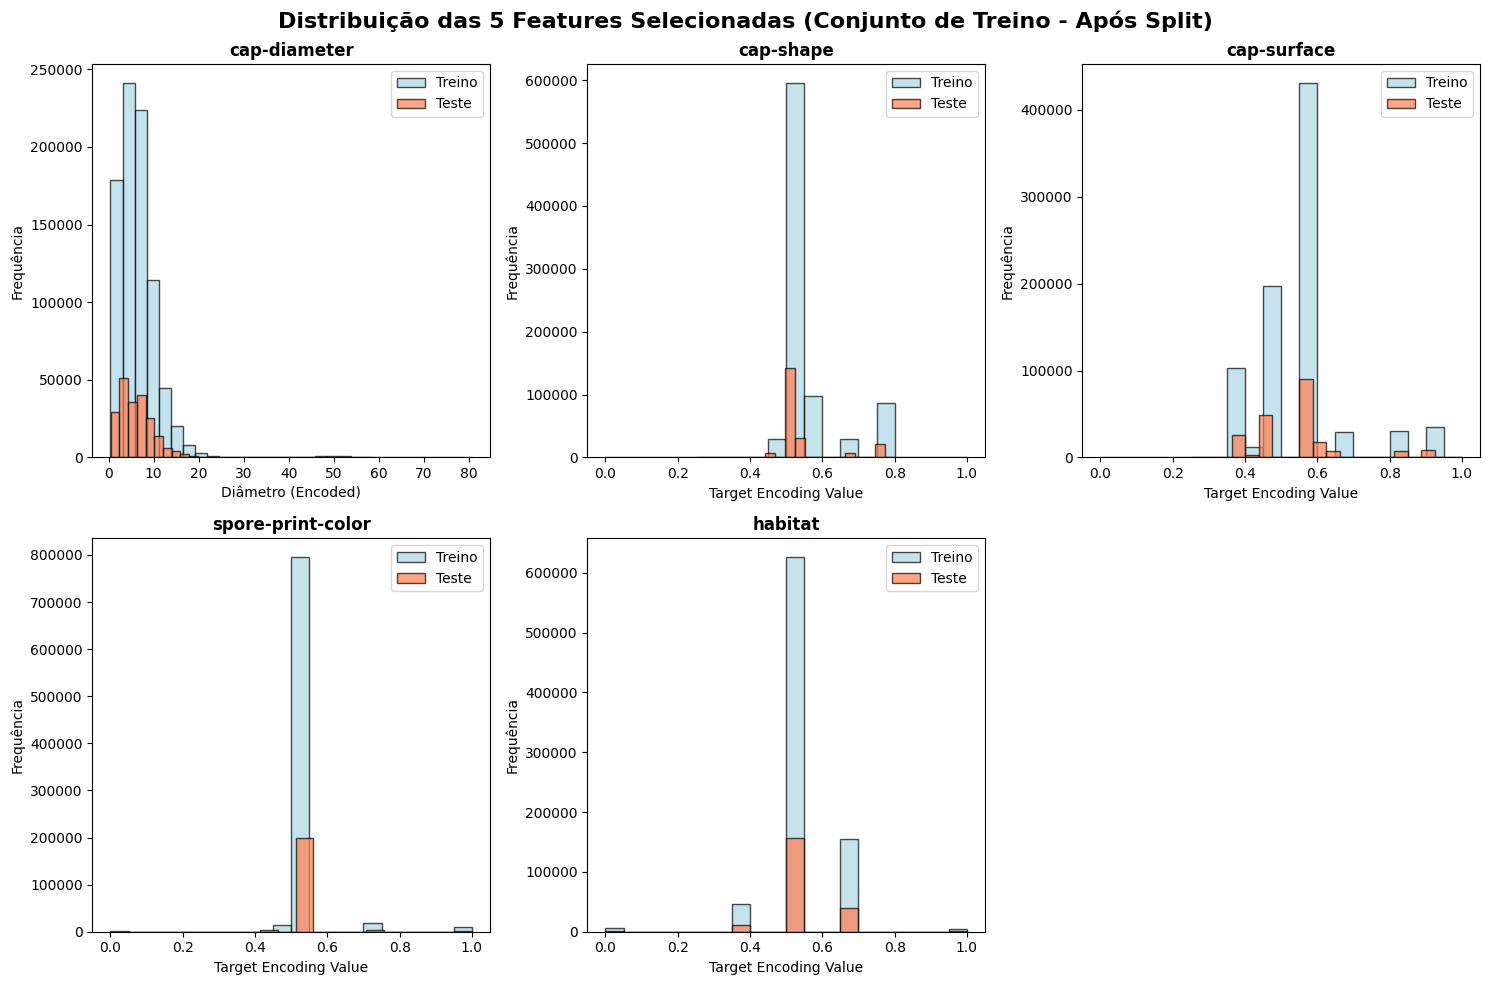

In [ ]:
# Celula 15 - Verificação do split das 5 features
print("=" * 70)
print("VERIFICAÇÃO DO SPLIT DO DATASET")
print("=" * 70)
print(f"\nTreino: {X_train.shape}")
print(f"Teste: {X_test.shape}")
print(f"\nClasses no Treino:")
print(y_train.value_counts())
print(f"\nClasses no Teste:")
print(y_test.value_counts())

# Visualização das 5 features após split e encoding
print("\n" + "=" * 70)
print("VISUALIZAÇÃO DAS 5 FEATURES (Treino) APÓS SPLIT")
print("=" * 70 + "\n")

selected_features = ['cap-diameter', 'cap-shape', 'cap-surface', 'spore-print-color', 'habitat']

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('Distribuição das 5 Features Selecionadas (Conjunto de Treino - Após Split)', fontsize=16, fontweight='bold')

# Plot 1: Histograma de cap-diameter no treino
axes[0, 0].hist(X_train['cap-diameter'].dropna(), bins=30, color='lightblue', alpha=0.7, label='Treino', edgecolor='black')
axes[0, 0].hist(X_test['cap-diameter'].dropna(), bins=30, color='coral', alpha=0.7, label='Teste', edgecolor='black')
axes[0, 0].set_title('cap-diameter', fontweight='bold')
axes[0, 0].set_xlabel('Diâmetro (Encoded)')
axes[0, 0].set_ylabel('Frequência')
axes[0, 0].legend()

# Plot 2-5: Gráficos de barras para features categóricas (encoding)
categorical_features = ['cap-shape', 'cap-surface', 'spore-print-color', 'habitat']
positions = [(0, 1), (0, 2), (1, 0), (1, 1)]

for feature, pos in zip(categorical_features, positions):
    axes[pos].hist(X_train[feature].dropna(), bins=20, color='lightblue', alpha=0.7, label='Treino', edgecolor='black')
    axes[pos].hist(X_test[feature].dropna(), bins=20, color='coral', alpha=0.7, label='Teste', edgecolor='black')
    axes[pos].set_title(feature, fontweight='bold')
    axes[pos].set_xlabel('Target Encoding Value')
    axes[pos].set_ylabel('Frequência')
    axes[pos].legend()

# Remover o último subplot vazio
axes[1, 2].remove()

plt.tight_layout()
plt.show()


## 📊 Análise dos Gráficos - Split do Dataset

**O que cada gráfico analisa?**

1. **cap-diameter**: Distribuição de diâmetro em treino vs teste.
   - **O que está acontecendo**: Sobreposição das distribuições entre treino (azul) e teste (coral), indicando que ambos conjuntos têm características similares.
   - **Motivo**: Verificar se o split mantém a representatividade dos dados é crucial para evitar viés de generalização.
   - **Conclusão**: A distribuição é equilibrada entre treino e teste, garantindo que o modelo aprenherá padrões generalizáveis.

2. **cap-shape**: Distribuição de target encoding para formato do chapéu.
   - **O que está acontecendo**: Os valores encoded (mapeamento target-based) aparecem bem distribuídos tanto no treino quanto no teste.
   - **Motivo**: O target encoding transforma categorias em valores numéricos baseado na proporção de classe (comestível/venenoso).
   - **Conclusão**: O encoding foi bem aplicado e ambos conjuntos mantêm a proporção adequada.

3. **cap-surface**: Distribuição da superfície do chapéu (encoded).
   - **O que está acontecendo**: Distribuição semelhante entre treino e teste.
   - **Motivo**: A simetria entre conjuntos garante que o modelo não aprenha artefatos específicos de um deles.
   - **Conclusão**: Split stratificado garantiu balanceamento de classes entre os conjuntos.

4. **spore-print-color**: Distribuição da cor de esporos (encoded).
   - **O que está acontecendo**: Histogramas sobrepostos indicam boa representatividade nos dois conjuntos.
   - **Motivo**: Esta feature tem alto poder discriminativo; é crítico que ambos treino e teste tenham cobertura completa.
   - **Conclusão**: Cobertura uniforme garante que o modelo terá exposição equilibrada a todos os tipos.

5. **habitat**: Distribuição de ambientes (encoded).
   - **O que está acontecendo**: Distribuições paralelas indicam que ambos conjuntos têm proporções semelhantes de habitats.
   - **Motivo**: Habitats raros precisam estar em ambos os conjuntos para testes rigorosos.
   - **Conclusão**: O split manteve a proporção de habitats raros, evitando viés de generalização.

**Conclusão Geral**: 
- O split 80/20 com `stratify=y` garantiu que ambos conjuntos (treino e teste) mantêm as mesmas proporções de classe.
- As distribuições das features são equilibradas, não apresentando viés de seleção.
